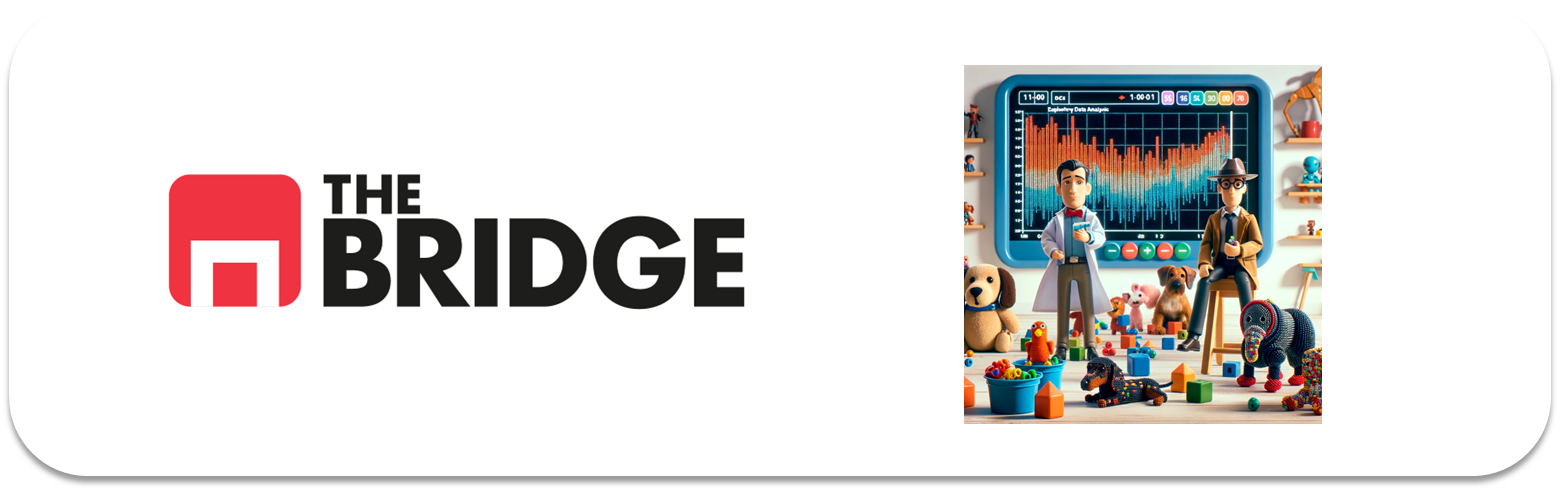

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df = pd.read_csv("./data/titanic.csv")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [3]:

df = df.drop(columns=["deck", "survived", "pclass", "embarked"])

# Verificamos que ya no estén
print(df.columns)


Index(['sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male',
       'embark_town', 'alive', 'alone'],
      dtype='object')


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [4]:

df["family_members"] = df["parch"] + df["sibsp"]

# Eliminamos las columnas originales
df = df.drop(columns=["parch", "sibsp"])

# Verificamos que la nueva columna existe y las antiguas ya no
print(df[["family_members"]].head())
print(df.columns)


   family_members
0               1
1               1
2               0
3               1
4               0
Index(['sex', 'age', 'fare', 'class', 'who', 'adult_male', 'embark_town',
       'alive', 'alone', 'family_members'],
      dtype='object')


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [5]:
# Calculamos la moda de embark_town
mode_value = df["embark_town"].mode()[0]

# Imputamos los nulos con la moda
df["embark_town"] = df["embark_town"].fillna(mode_value)

# Verificamos que ya no haya nulos
print(df["embark_town"].isna().sum())
print("Moda utilizada:", mode_value)


0
Moda utilizada: Southampton


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [6]:
# Calculamos la media de edad por cada categoría de 'who'
mean_by_who = df.groupby("who")["age"].transform("mean")

# Imputamos los nulos de 'age' con la media correspondiente a su grupo 'who'
df["age"] = df["age"].fillna(mean_by_who)

# Verificamos
print(df[["who", "age"]].head())
print("Nulos restantes en age:", df["age"].isna().sum())

     who   age
0    man  22.0
1  woman  38.0
2  woman  26.0
3  woman  35.0
4    man  35.0
Nulos restantes en age: 0


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [12]:
# Convertimos alive a binario (1=survivió, 0=no)
df["alive_bin"] = (df["alive"] == "yes").astype(int)

# Supervivientes absolutos por sexo
abs_sex = df[df["alive_bin"]==1]["sex"].value_counts()

# Supervivientes absolutos por who (man, woman, child)
abs_who = df[df["alive_bin"]==1]["who"].value_counts()

print("Supervivientes absolutos por sexo:\n", abs_sex)
print("Supervivientes absolutos por who:\n", abs_who)

Supervivientes absolutos por sexo:
 sex
female    233
male      109
Name: count, dtype: int64
Supervivientes absolutos por who:
 who
woman    205
man       88
child     49
Name: count, dtype: int64


In [13]:
# Tasa de supervivencia por sexo
rel_sex = df.groupby("sex")["alive_bin"].mean()

# Tasa de supervivencia por who
rel_who = df.groupby("who")["alive_bin"].mean()

print("Tasa de supervivencia por sexo:\n", rel_sex)
print("Tasa de supervivencia por who:\n", rel_who)

Tasa de supervivencia por sexo:
 sex
female    0.742038
male      0.188908
Name: alive_bin, dtype: float64
Tasa de supervivencia por who:
 who
child    0.590361
man      0.163873
woman    0.756458
Name: alive_bin, dtype: float64


In [14]:
from scipy.stats import chi2_contingency
import pandas as pd

# Sexo vs supervivencia
ct_sex = pd.crosstab(df["sex"], df["alive_bin"])
chi_sex = chi2_contingency(ct_sex)

# Adulto/niño (derivado de who)
df["is_child"] = (df["who"]=="child").astype(int)
ct_child = pd.crosstab(df["is_child"], df["alive_bin"])
chi_child = chi2_contingency(ct_child)

print("Chi2 sexo vs supervivencia:", chi_sex[0], "p-valor:", chi_sex[1])
print("Chi2 adulto/niño vs supervivencia:", chi_child[0], "p-valor:", chi_child[1])

Chi2 sexo vs supervivencia: 260.71702016732104 p-valor: 1.1973570627755645e-58
Chi2 adulto/niño vs supervivencia: 15.556993340077092 p-valor: 8.005497211300105e-05


**PREGUNTA 2**

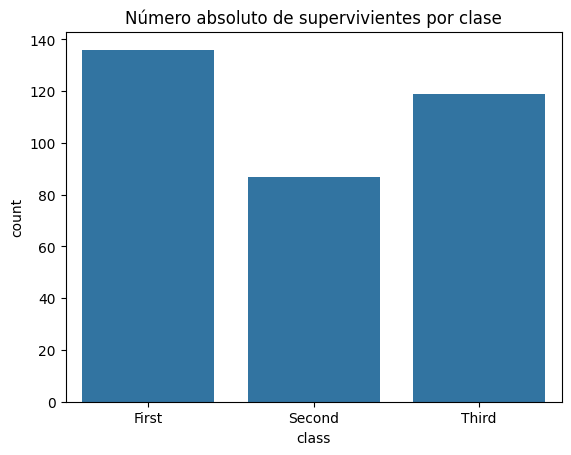

In [15]:

# Filtramos solo los que sobrevivieron
survivors = df[df["alive"]=="yes"]

sns.countplot(data=survivors, x="class", order=["First","Second","Third"])
plt.title("Número absoluto de supervivientes por clase")
plt.show()

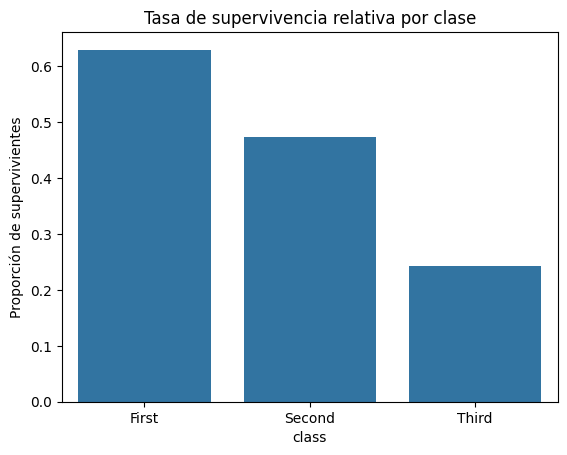

In [16]:
survival_rate = df.groupby("class")["alive"].apply(lambda x: (x=="yes").mean()).reset_index()

sns.barplot(data=survival_rate, x="class", y="alive", order=["First","Second","Third"])
plt.title("Tasa de supervivencia relativa por clase")
plt.ylabel("Proporción de supervivientes")
plt.show()

In [17]:

ct_class = pd.crosstab(df["class"], df["alive"])
chi2, p, dof, expected = chi2_contingency(ct_class)

print("Chi-cuadrado:", chi2, "p-valor:", p)

Chi-cuadrado: 102.88898875696056 p-valor: 4.549251711298793e-23


3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

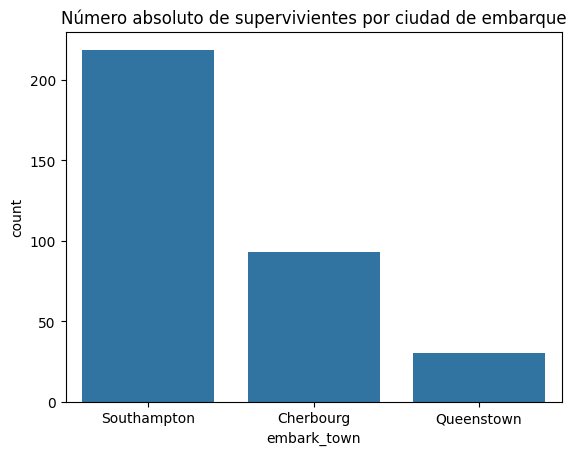

In [23]:

# Filtramos solo los que sobrevivieron
survivors = df[df["alive"]=="yes"]

sns.countplot(data=survivors, x="embark_town", order=["Southampton","Cherbourg","Queenstown"])
plt.title("Número absoluto de supervivientes por ciudad de embarque")
plt.show()

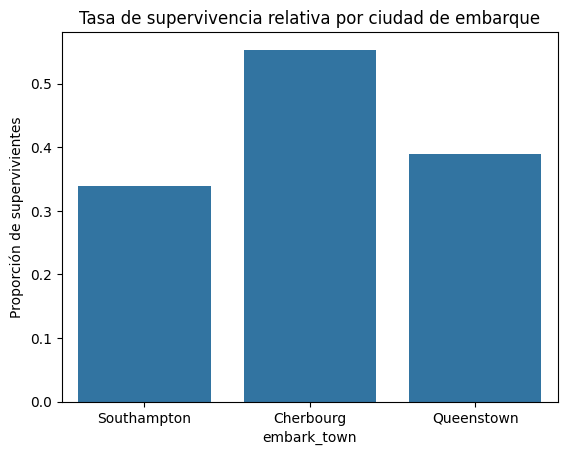

In [24]:
survival_rate = df.groupby("embark_town")["alive"].apply(lambda x: (x=="yes").mean()).reset_index()

sns.barplot(data=survival_rate, x="embark_town", y="alive", order=["Southampton","Cherbourg","Queenstown"])
plt.title("Tasa de supervivencia relativa por ciudad de embarque")
plt.ylabel("Proporción de supervivientes")
plt.show()

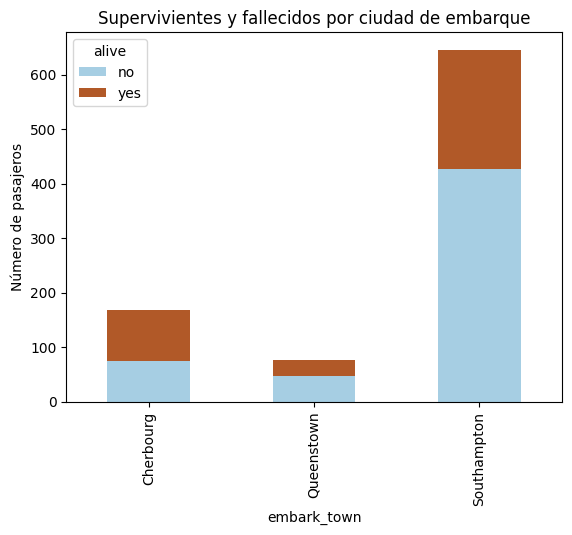

In [25]:
ct_town = pd.crosstab(df["embark_town"], df["alive"])

ct_town.plot(kind="bar", stacked=True, colormap="Paired")
plt.title("Supervivientes y fallecidos por ciudad de embarque")
plt.ylabel("Número de pasajeros")
plt.show()

In [26]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct_town)
print("Chi-cuadrado:", chi2, "p-valor:", p)

Chi-cuadrado: 25.964452881874784 p-valor: 2.3008626481449577e-06


4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

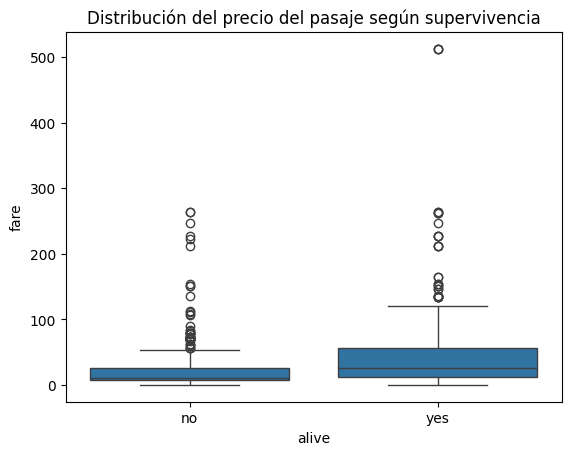

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asegúrate de tener la columna binaria de supervivencia
df["alive_bin"] = (df["alive"]=="yes").astype(int)

# -------------------------------
# 4. Precio del pasaje vs supervivencia
# -------------------------------
sns.boxplot(data=df, x="alive", y="fare")
plt.title("Distribución del precio del pasaje según supervivencia")
plt.show()


5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

In [28]:
# -------------------------------
# 5. Pasajeros con fare=0 y máximo fare
# -------------------------------
free_passengers = df[df["fare"]==0]
print("Pasajeros con fare=0:\n", free_passengers[["class","sex","who","embark_town","alive"]])

max_fare = df.loc[df["fare"].idxmax()]
print("Pasajero con máximo fare:\n", max_fare[["class","sex","who","embark_town","alive","fare"]])

Pasajeros con fare=0:
       class   sex  who  embark_town alive
179   Third  male  man  Southampton    no
263   First  male  man  Southampton    no
271   Third  male  man  Southampton   yes
277  Second  male  man  Southampton    no
302   Third  male  man  Southampton    no
413  Second  male  man  Southampton    no
466  Second  male  man  Southampton    no
481  Second  male  man  Southampton    no
597   Third  male  man  Southampton    no
633   First  male  man  Southampton    no
674  Second  male  man  Southampton    no
732  Second  male  man  Southampton    no
806   First  male  man  Southampton    no
815   First  male  man  Southampton    no
822   First  male  man  Southampton    no
Pasajero con máximo fare:
 class              First
sex               female
who                woman
embark_town    Cherbourg
alive                yes
fare            512.3292
Name: 258, dtype: object


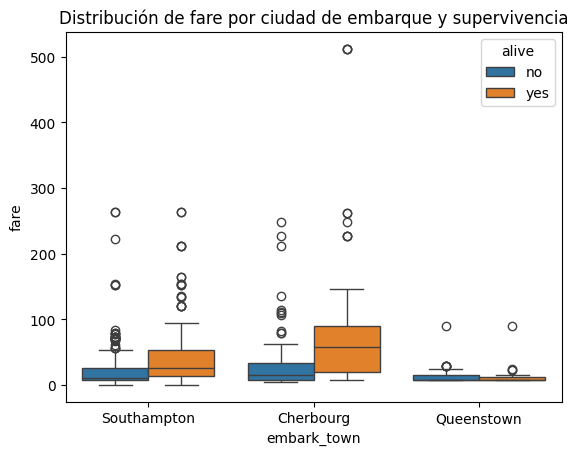

In [29]:
# -------------------------------
# 6. Dinero pagado × ciudad de embarque × supervivencia
# -------------------------------
sns.boxplot(data=df, x="embark_town", y="fare", hue="alive")
plt.title("Distribución de fare por ciudad de embarque y supervivencia")
plt.show()

C:\Users\blanc.TORRE-BLANCA\AppData\Local\Temp\ipykernel_23700\4229217248.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  abs_counts = df[df["alive_bin"]==1].groupby(["class","age_group"]).size().reset_index(name="count")


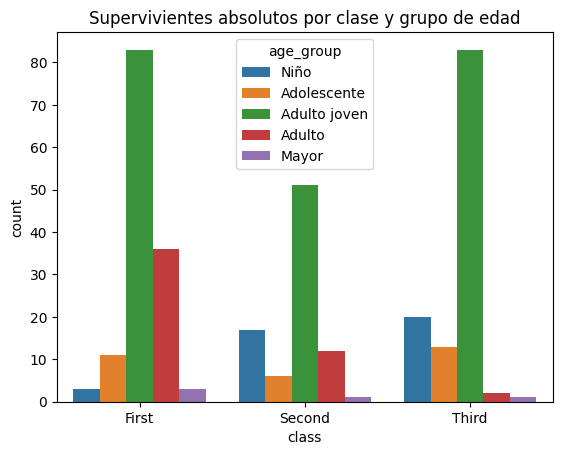

C:\Users\blanc.TORRE-BLANCA\AppData\Local\Temp\ipykernel_23700\4229217248.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rel_rates = df.groupby(["class","age_group"])["alive_bin"].mean().reset_index()


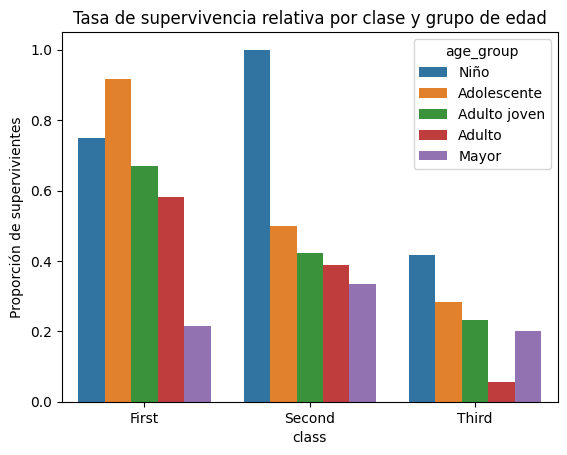

In [30]:
# -------------------------------
# 7. Clase × edad vs supervivencia
# -------------------------------
# Agrupamos edades en categorías
bins = [0, 12, 18, 40, 60, 100]
labels = ["Niño","Adolescente","Adulto joven","Adulto","Mayor"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# Absolutos: número de supervivientes por combinación
abs_counts = df[df["alive_bin"]==1].groupby(["class","age_group"]).size().reset_index(name="count")
sns.barplot(data=abs_counts, x="class", y="count", hue="age_group")
plt.title("Supervivientes absolutos por clase y grupo de edad")
plt.show()

# Relativos: tasa de supervivencia por combinación
rel_rates = df.groupby(["class","age_group"])["alive_bin"].mean().reset_index()
sns.barplot(data=rel_rates, x="class", y="alive_bin", hue="age_group")
plt.title("Tasa de supervivencia relativa por clase y grupo de edad")
plt.ylabel("Proporción de supervivientes")
plt.show()

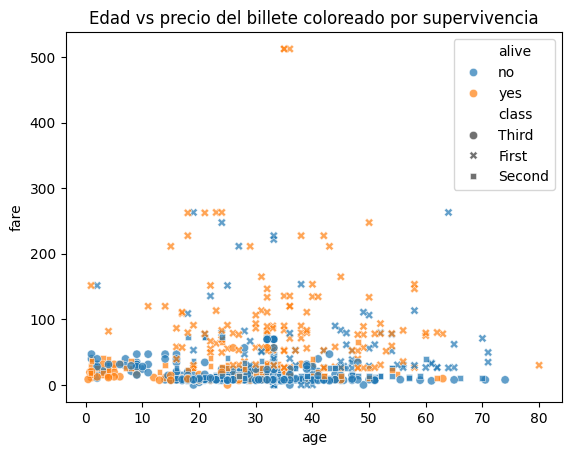

In [31]:
# -------------------------------
# 8. Edad × coste del billete × supervivencia
# -------------------------------
sns.scatterplot(data=df, x="age", y="fare", hue="alive", style="class", alpha=0.7)
plt.title("Edad vs precio del billete coloreado por supervivencia")
plt.show()

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?